<a href="https://colab.research.google.com/github/MonseMontesBocanegra/4105_IntroML/blob/Assignments/MonseMontesBocanegra_801297280_Homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best Accuracy: 0.9912
Best Kernel: linear
Optimal Number of Principal Components (K): 2


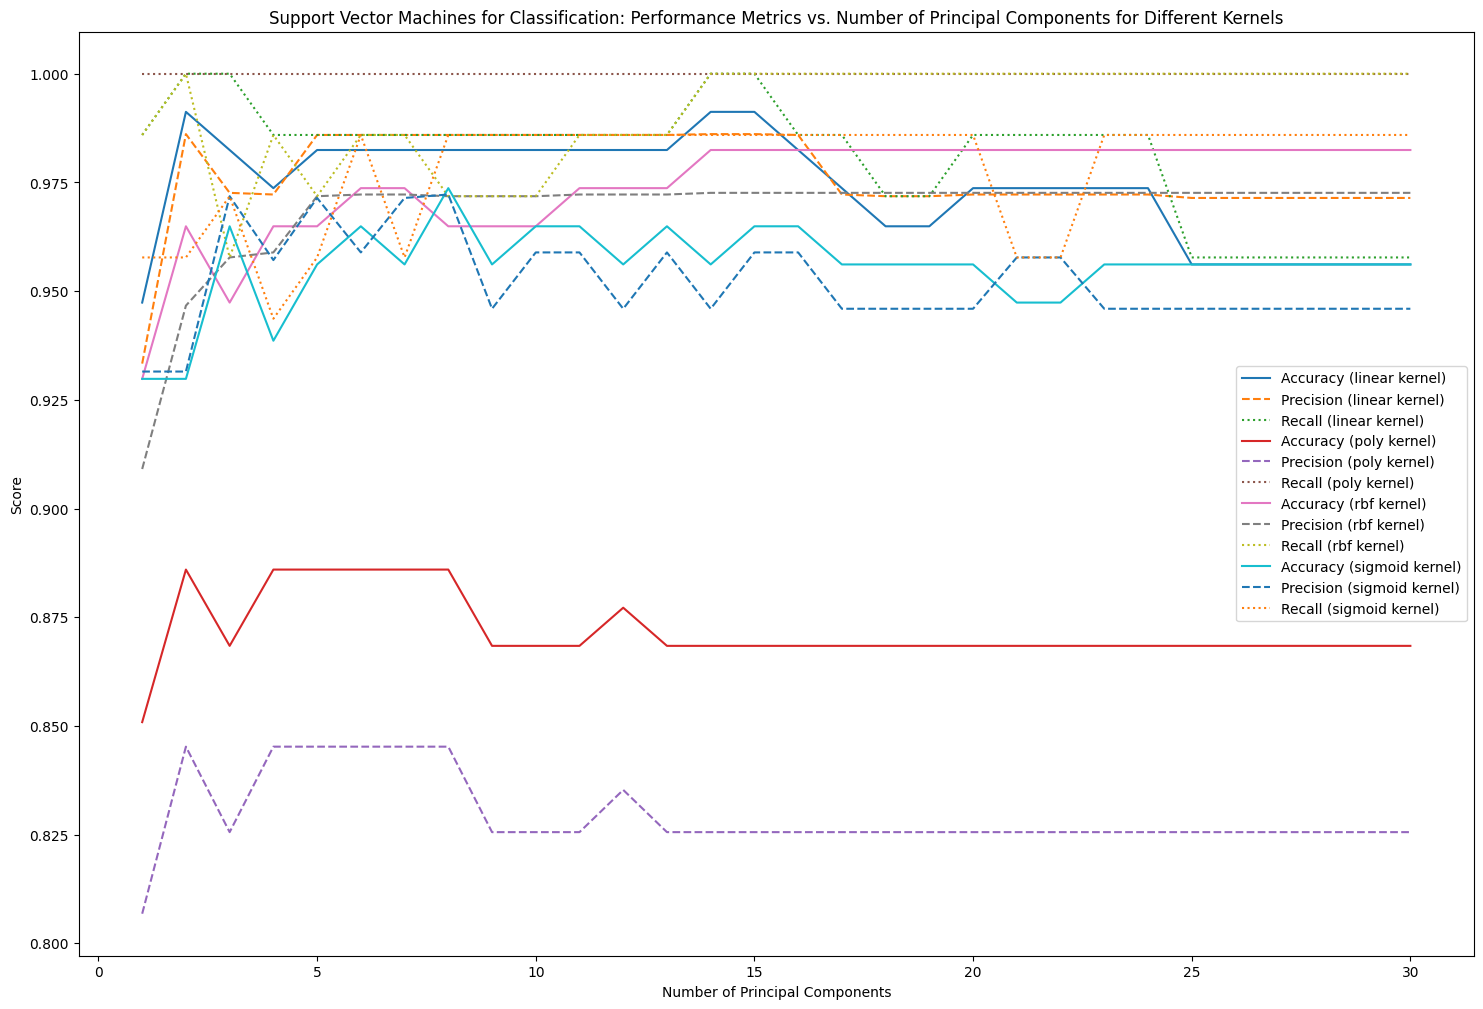

In [18]:
#Part 1 and 2 and 3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

breast = load_breast_cancer()
X = breast.data
y = breast.target

# (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

accuracies = []
precisions = []
recalls = []
components_range = range(1, X.shape[1] + 1)

kernel_accuracies = {k: [] for k in ['linear', 'poly', 'rbf', 'sigmoid']}
kernel_precisions = {k: [] for k in ['linear', 'poly', 'rbf', 'sigmoid']}
kernel_recalls = {k: [] for k in ['linear', 'poly', 'rbf', 'sigmoid']}
best_accuracy = 0
best_kernel = None
best_n_components = 0


for n_components in components_range:
    # PCA
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    for kernel in kernel_accuracies.keys():
        # SVM classifier
        svm = SVC(kernel=kernel, random_state=42)
        svm.fit(X_train_pca, y_train)

        y_pred = svm.predict(X_test_pca)
        accuracy = accuracy_score(y_test, y_pred)
        kernel_accuracies[kernel].append(accuracy)
        kernel_precisions[kernel].append(precision_score(y_test, y_pred))
        kernel_recalls[kernel].append(recall_score(y_test, y_pred))

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_kernel = kernel
            best_n_components = n_components

print(f"Best Accuracy: {best_accuracy:.4f}")
print(f"Best Kernel: {best_kernel}")
print(f"Optimal Number of Principal Components (K): {best_n_components}")

plt.figure(figsize=(18, 12))
for kernel in kernel_accuracies.keys():
    plt.plot(components_range, kernel_accuracies[kernel], label=f"Accuracy ({kernel} kernel)")
    plt.plot(components_range, kernel_precisions[kernel], '--', label=f"Precision ({kernel} kernel)")
    plt.plot(components_range, kernel_recalls[kernel], ':', label=f"Recall ({kernel} kernel)")

plt.xlabel('Number of Principal Components')
plt.ylabel('Score')
plt.title('Support Vector Machines for Classification: Performance Metrics vs. Number of Principal Components for Different Kernels')
plt.legend()
plt.show()



Problem 2


Optimal number of components for linear kernel: 4, R^2 Score: 0.5903
Optimal number of components for rbf kernel: 1, R^2 Score: 0.6124
Optimal number of components for poly kernel: 1, R^2 Score: 0.5149
RBF Predictions: [6195527.49825546 6760385.13199045 6221728.62553014 5085544.42474953
 4042196.79939807]
Actual Test Values: [7070000 4550000 5600000 6125000 2940000]
R² Score for RBF: 0.6124


<ipython-input-38-9ef3de4cf52c>:80: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_range = np.array([[area, mean_values[1], mean_values[2], mean_values[3],
<ipython-input-38-9ef3de4cf52c>:81: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_values[4], mean_values[5], mean_values[6],
<ipython-input-38-9ef3de4cf52c>:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_values[7], mean_values[8], mean_values[9],
<ipython-input-38-9

Linear Predictions: [6079821.99476967 6414861.32396215 6094284.02994507 5264224.11380615
 4092798.02914356]
Actual Test Values: [7070000 4550000 5600000 6125000 2940000]
R² Score for Linear: 0.5767
Polynomial Predictions: [4821836.51679652 5178064.17698362 4835640.70422773 4272952.86677561
 4274065.42954675]
Actual Test Values: [7070000 4550000 5600000 6125000 2940000]
R² Score for Polynomial: 0.1698


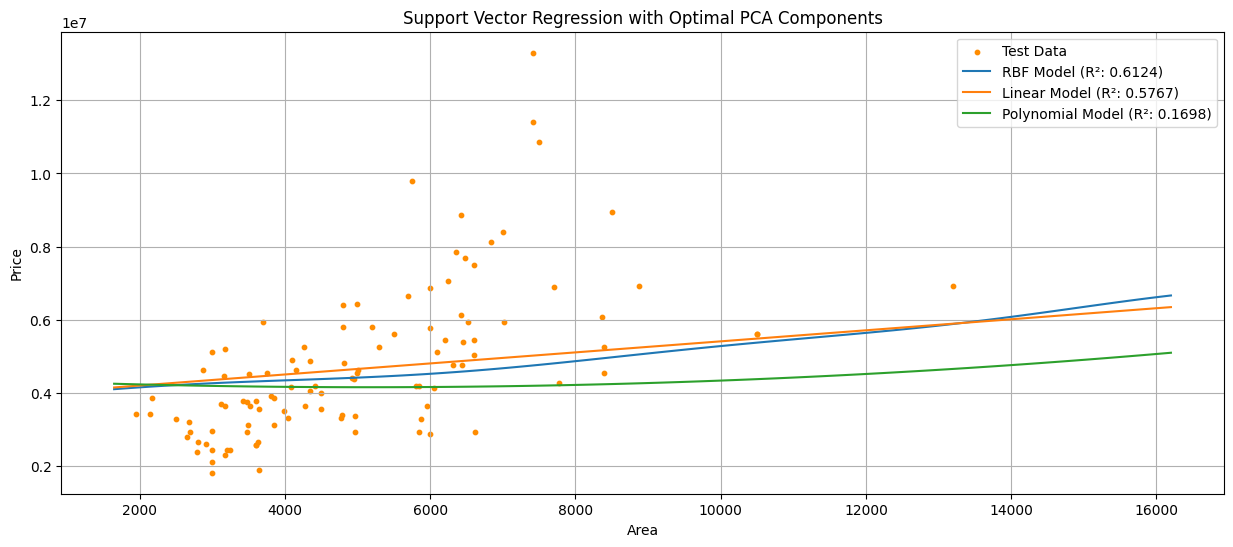

The best regression model is: RBF with an R^2 score of 0.6124


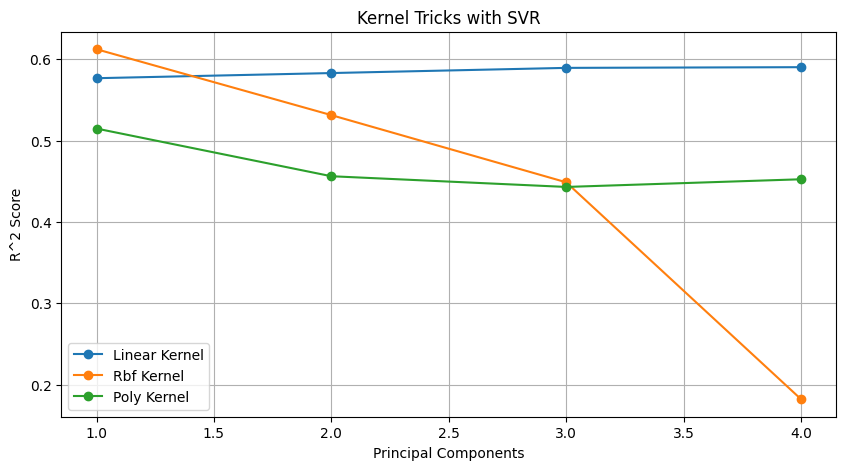

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


data = pd.read_csv('https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/refs/heads/main/Dataset/Housing.csv')


input_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
                  'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
                  'parking', 'prefarea']
X = data[input_features]
y = data['price'].values


X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
X_test_scaled = scaler_X.transform(X_test)

# Fit regression models with different kernels and track R^2 scores for PCA components
components_range = list(range(1, 5))
kernels = ['linear', 'rbf', 'poly']  # Kernel types
optimal_k = {kernel: (0, 0) for kernel in kernels}


r2_scores_dict = {kernel: [] for kernel in kernels}

for kernel in kernels:
    for n_components in components_range:
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_train_scaled)

        svr_model = SVR(kernel=kernel, C=1e3)
        svr_model.fit(X_pca, y_train_scaled)


        X_test_pca = pca.transform(X_test_scaled)
        y_pred = svr_model.predict(X_test_pca)

        r2 = r2_score(y_test, scaler_y.inverse_transform(y_pred.reshape(-1, 1)))

        r2_scores_dict[kernel].append(r2)


        if r2 > optimal_k[kernel][1]:
            optimal_k[kernel] = (n_components, r2)


for kernel, (k, r2) in optimal_k.items():
    print(f'Optimal number of components for {kernel} kernel: {k}, R^2 Score: {r2:.4f}')


optimal_components = optimal_k['rbf'][0]
pca = PCA(n_components=optimal_components)
X_train_pca = pca.fit_transform(X_train_scaled)

svr_models = {
    'RBF': SVR(kernel='rbf', C=1e3),
    'Linear': SVR(kernel='linear', C=1e3),
    'Polynomial': SVR(kernel='poly', C=1e3, degree=2)
}


y_predictions = {}
r2_scores = {}

area_range = np.linspace(X['area'].min(), X['area'].max(), 100)
mean_values = np.mean(X_encoded, axis=0)
X_range = np.array([[area, mean_values[1], mean_values[2], mean_values[3],
                     mean_values[4], mean_values[5], mean_values[6],
                     mean_values[7], mean_values[8], mean_values[9],
                     mean_values[10]] for area in area_range])
X_range_scaled = scaler_X.transform(X_range)
X_range_pca = pca.transform(X_range_scaled)


for name, model in svr_models.items():
    model.fit(X_train_pca, y_train_scaled)
    y_pred_range = model.predict(X_range_pca)
    y_predictions[name] = scaler_y.inverse_transform(y_pred_range.reshape(-1, 1))
    y_test_pca = pca.transform(X_test_scaled)
    y_pred_test = model.predict(y_test_pca)
    y_pred_test_inverse = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1))
    r2 = r2_score(y_test, y_pred_test_inverse)
    r2_scores[name] = r2

    print(f'{name} Predictions: {y_pred_test_inverse[:5].flatten()}')
    print(f'Actual Test Values: {y_test[:5]}')
    print(f'R² Score for {name}: {r2:.4f}')



plt.figure(figsize=(15, 6))
plt.scatter(X_test['area'], y_test, color='darkorange', label='Test Data', s=10)


for name, predictions in y_predictions.items():
    plt.plot(area_range, predictions, label=f'{name} Model (R²: {r2_scores[name]:.4f})')

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Support Vector Regression with Optimal PCA Components')
plt.legend()
plt.grid()
plt.show()

best_model = max(r2_scores, key=r2_scores.get)
print(f'The best regression model is: {best_model} with an R^2 score of {r2_scores[best_model]:.4f}')


plt.figure(figsize=(10, 5))
plt.title('Kernel Tricks with SVR')
plt.xlabel('Principal Components')
plt.ylabel('R^2 Score')


for kernel in kernels:
    plt.plot(components_range, r2_scores_dict[kernel], marker='o', label=f'{kernel.capitalize()} Kernel')

plt.legend()
plt.grid()
plt.show()
